In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

In [2]:
#Generer un dataset 3D (100 points)
np.random.seed(42)
X = np.random.rand(100, 3) * [10, 1, 0.1]  # colonnes sur des echelles differentes

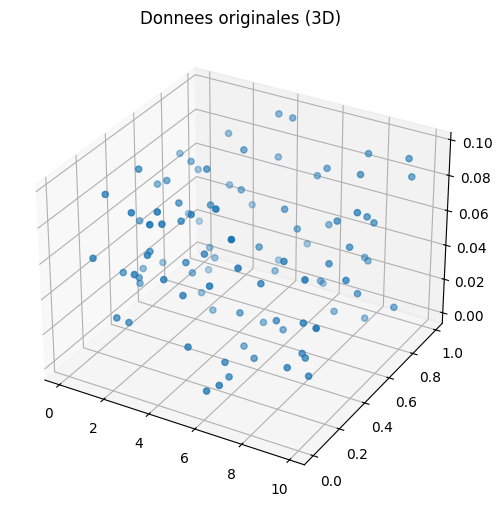

In [3]:
#Visualiser les donnees originales en 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2])
ax.set_title("Donnees originales (3D)")
plt.show()

In [4]:
#Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# PCA pour reduction en 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [6]:
print("Forme avant PCA :", X_scaled.shape)  # (100, 3)
print("Forme apres PCA :", X_pca.shape)    # (100, 2)
print("Variance expliquee par chaque composante :", pca.explained_variance_ratio_)
print("Variance totale conservée :", np.sum(pca.explained_variance_ratio_))

Forme avant PCA : (100, 3)
Forme apres PCA : (100, 2)
Variance expliquee par chaque composante : [0.37032399 0.32900197]
Variance totale conservée : 0.6993259531245215


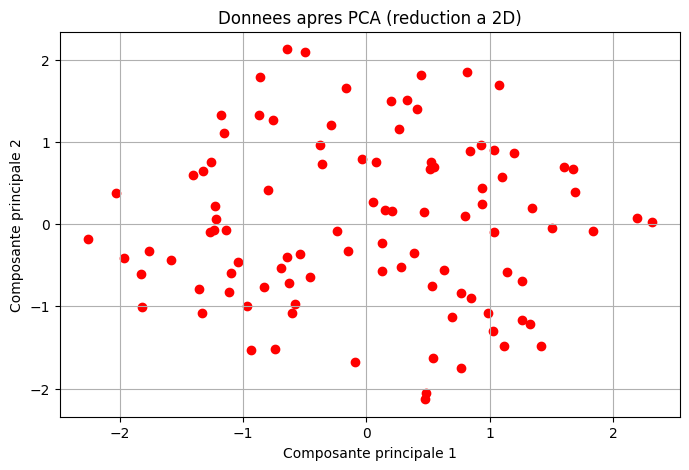

In [7]:

#Visualiser le resultat apres reduction
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='red')
plt.title("Donnees apres PCA (reduction a 2D)")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.grid(True)
plt.show()

Using Auto Encoder

In [8]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import matplotlib.pyplot as plt

In [9]:
# Generer les donnees
np.random.seed(0)
X = np.random.rand(1000, 3) * [10, 1, 0.1]
print(X)

[[5.48813504 0.71518937 0.06027634]
 [5.44883183 0.4236548  0.06458941]
 [4.37587211 0.891773   0.09636628]
 ...
 [4.75214033 0.28729288 0.08796815]
 [2.84927053 0.94168707 0.05461327]
 [3.2361371  0.81354502 0.06974004]]


In [10]:
#Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
X_scaled.shape[1]

3

In [12]:
input_dim = X_scaled.shape[1]
encoding_dim =2

In [13]:
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='linear')(encoded)

In [14]:
autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

In [15]:
#Entrainer le modele
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=0)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


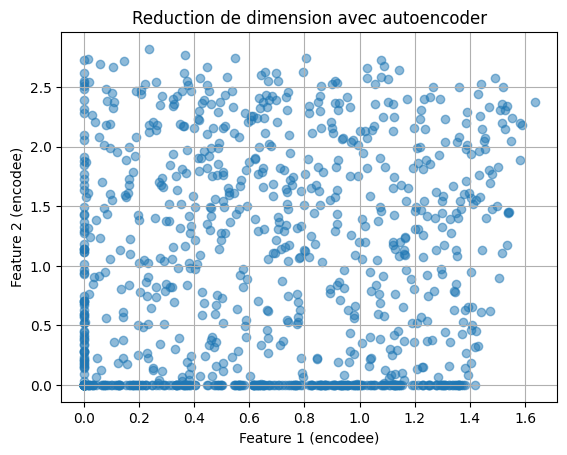

In [16]:

#Extraire la partie "encodeur"
encoder = Model(inputs=input_layer, outputs=encoded)
X_reduced = encoder.predict(X_scaled)

# Visualiser la reduction
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], alpha=0.5)
plt.title("Reduction de dimension avec autoencoder")
plt.xlabel("Feature 1 (encodee)")
plt.ylabel("Feature 2 (encodee)")
plt.grid(True)